# Notebook 08 - Comparación de modelos

En este notebook consolidamos y comparamos los resultados de todos los modelos implementados: MLP, CNN, RNN, LSTM, GRU y Transformer.

## 1. Importaciones

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings
warnings.filterwarnings('ignore')

print('Librerías cargadas')

Librerías cargadas


## 2. Carga de métricas de todos los modelos

In [12]:
MODELS_DIR = '../models'
archivos_metricas = [
    'metricas_mlp.json',
    'metricas_cnn.json',
    'metricas_rnn.json',
    'metricas_lstm.json',
    'metricas_gru.json',
    'metricas_transformer.json'
]

lista_metricas = []
for archivo in archivos_metricas:
    ruta = os.path.join(MODELS_DIR, archivo)
    if os.path.exists(ruta):
        with open(ruta, 'r') as f:
            lista_metricas.append(json.load(f))
    else:
        print(f'Archivo no encontrado: {archivo} (ejecuta el notebook correspondiente primero)')

df_metricas = pd.DataFrame(lista_metricas)
df_metricas = df_metricas.set_index('modelo')
print('Modelos cargados:', df_metricas.index.tolist())

Modelos cargados: ['MLP', 'CNN', 'RNN', 'LSTM', 'GRU', 'Transformer']


## 3. Tabla comparativa de métricas

In [13]:
# Tabla formateada
df_display = df_metricas[['accuracy', 'precision', 'recall', 'f1', 'tiempo_entrenamiento']].copy()
df_display.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Tiempo (s)']
df_display = df_display.round({'Accuracy': 4, 'Precision': 4, 'Recall': 4, 'F1-Score': 4, 'Tiempo (s)': 1})

print('Comparación de Modelos - Dataset UCI HAR')
print('=' * 70)
print(df_display.to_string())
print()

mejor_modelo = df_metricas['accuracy'].idxmax()
print(f'Mejor modelo por Accuracy: {mejor_modelo} ({df_metricas.loc[mejor_modelo, "accuracy"]:.4f})')

Comparación de Modelos - Dataset UCI HAR
             Accuracy  Precision  Recall  F1-Score  Tiempo (s)
modelo                                                        
MLP            0.9406     0.9433  0.9406    0.9403        26.5
CNN            0.9267     0.9260  0.9267    0.9259       338.3
RNN            0.8317     0.8335  0.8317    0.8318       105.9
LSTM           0.9125     0.9121  0.9125    0.9121       479.7
GRU            0.8972     0.8991  0.8972    0.8972      1213.4
Transformer    0.9220     0.9246  0.9220    0.9215      1472.6

Mejor modelo por Accuracy: MLP (0.9406)


## 4. Gráfico comparativo de métricas principales

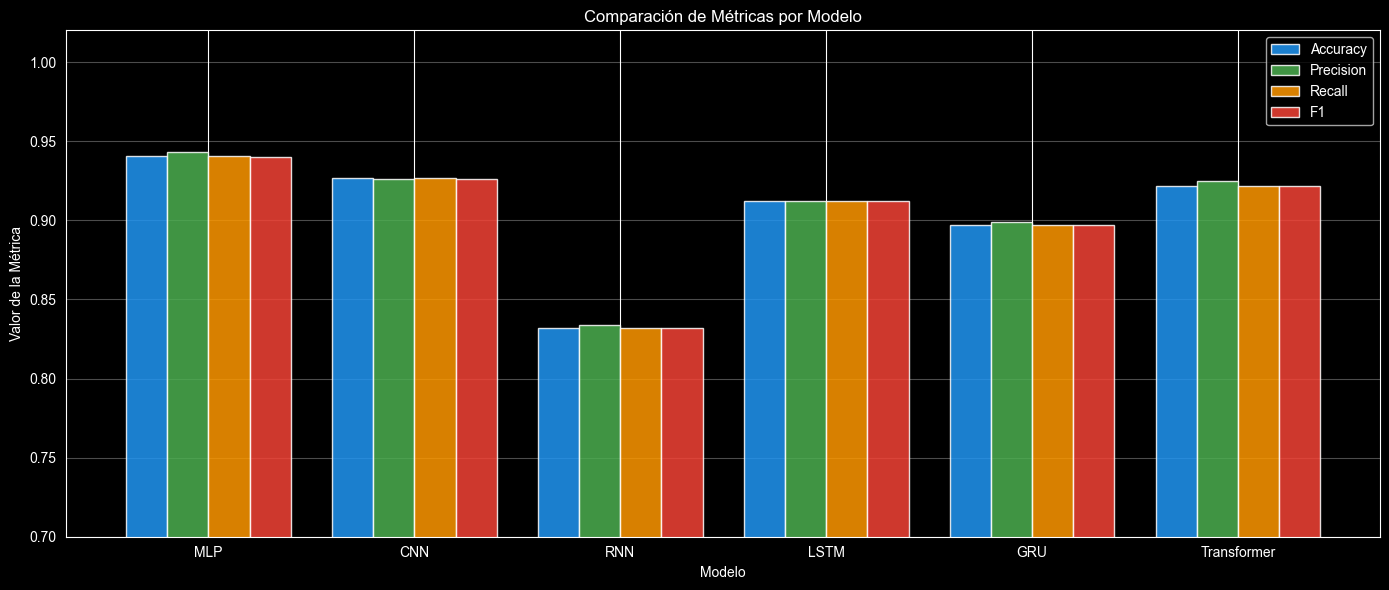

In [14]:
modelos = df_metricas.index.tolist()
metricas = ['accuracy', 'precision', 'recall', 'f1']
colores = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']

x = np.arange(len(modelos))
ancho = 0.2

fig, ax = plt.subplots(figsize=(14, 6))

for i, (metrica, color) in enumerate(zip(metricas, colores)):
    valores = df_metricas[metrica].values
    barras = ax.bar(x + i * ancho, valores, ancho, label=metrica.capitalize(), color=color, alpha=0.85)

ax.set_xlabel('Modelo')
ax.set_ylabel('Valor de la Métrica')
ax.set_title('Comparación de Métricas por Modelo')
ax.set_xticks(x + ancho * 1.5)
ax.set_xticklabels(modelos)
ax.set_ylim(0.7, 1.02)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/comparacion_metricas.png', dpi=100, bbox_inches='tight')
plt.show()

## 5. Comparación de Accuracy

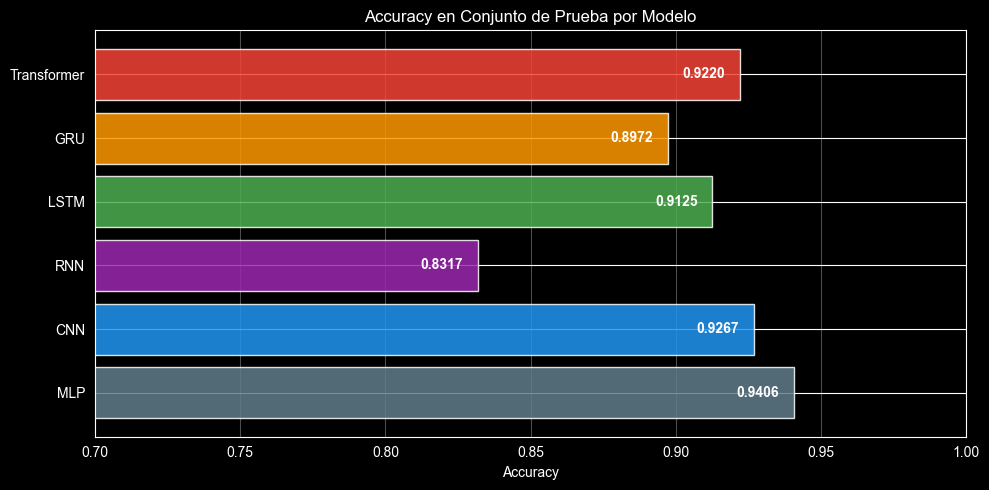

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

colores_modelos = ['#607D8B', '#2196F3', '#9C27B0', '#4CAF50', '#FF9800', '#F44336']
barras = ax.barh(modelos, df_metricas['accuracy'].values, color=colores_modelos, alpha=0.85)

# Añadir valores en las barras
for barra, valor in zip(barras, df_metricas['accuracy'].values):
    ax.text(valor - 0.005, barra.get_y() + barra.get_height() / 2,
            f'{valor:.4f}', ha='right', va='center', color='white', fontweight='bold')

ax.set_xlabel('Accuracy')
ax.set_title('Accuracy en Conjunto de Prueba por Modelo')
ax.set_xlim(0.7, 1.0)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/comparacion_accuracy.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Comparación de tiempo de entrenamiento

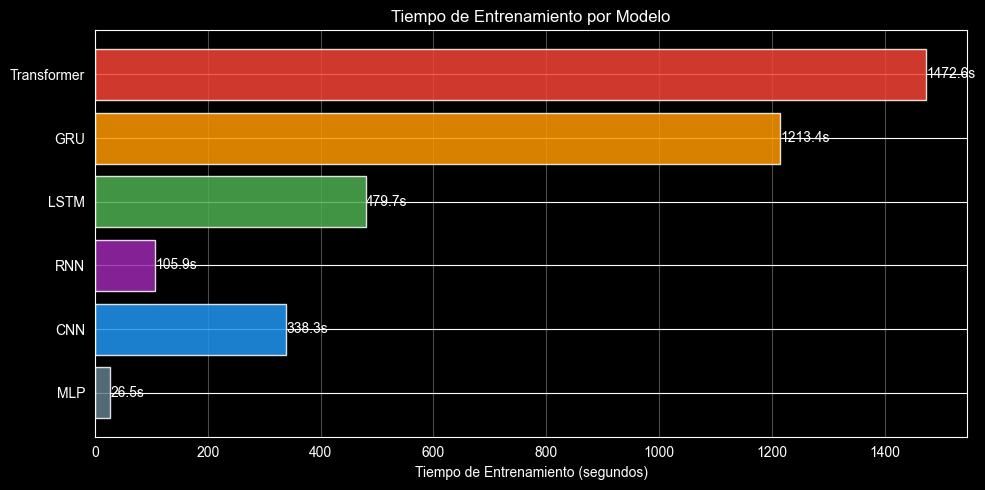

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

tiempos = df_metricas['tiempo_entrenamiento'].values
barras = ax.barh(modelos, tiempos, color=colores_modelos, alpha=0.85)

for barra, valor in zip(barras, tiempos):
    ax.text(valor + 1, barra.get_y() + barra.get_height() / 2,
            f'{valor:.1f}s', ha='left', va='center')

ax.set_xlabel('Tiempo de Entrenamiento (segundos)')
ax.set_title('Tiempo de Entrenamiento por Modelo')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/comparacion_tiempo.png', dpi=100, bbox_inches='tight')
plt.show()

## 7. Análisis de la relación Accuracy vs Tiempo

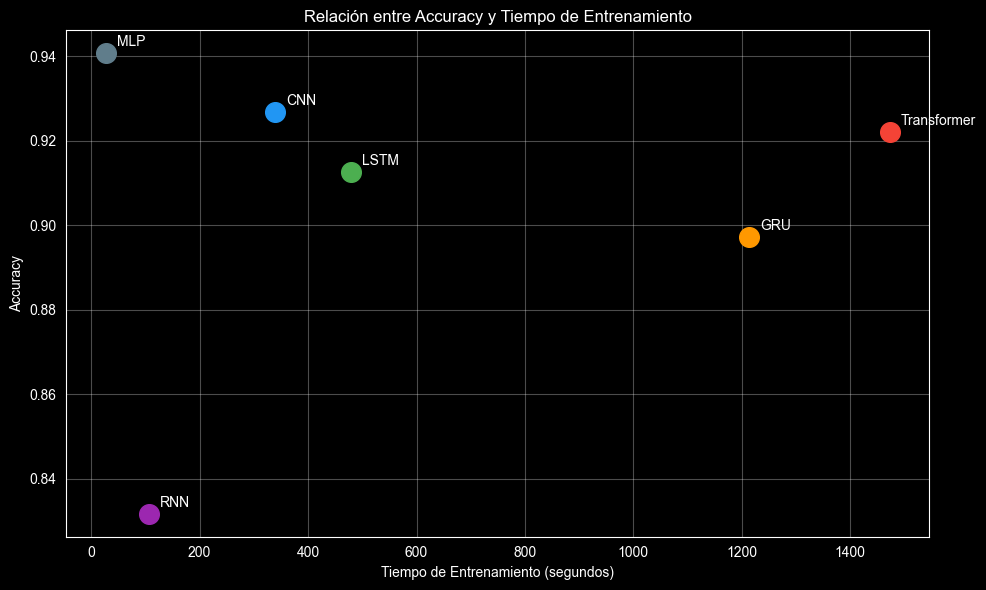

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

for i, (modelo, color) in enumerate(zip(modelos, colores_modelos)):
    ax.scatter(
        df_metricas.loc[modelo, 'tiempo_entrenamiento'],
        df_metricas.loc[modelo, 'accuracy'],
        color=color, s=200, zorder=5
    )
    ax.annotate(
        modelo,
        (df_metricas.loc[modelo, 'tiempo_entrenamiento'], df_metricas.loc[modelo, 'accuracy']),
        textcoords='offset points', xytext=(8, 5), fontsize=10
    )

ax.set_xlabel('Tiempo de Entrenamiento (segundos)')
ax.set_ylabel('Accuracy')
ax.set_title('Relación entre Accuracy y Tiempo de Entrenamiento')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/accuracy_vs_tiempo.png', dpi=100, bbox_inches='tight')
plt.show()

## 8. Tabla de complejidad de los modelos

Además de las métricas de desempeño, es importante considerar la complejidad de cada arquitectura desde una perspectiva práctica.

In [18]:
# Tabla cualitativa de complejidad
tabla_complejidad = {
    'Modelo': ['MLP', 'CNN', 'RNN', 'LSTM', 'GRU', 'Transformer'],
    'Datos de entrada': ['Tabular (561 feat)', 'Señal cruda (128x9)', 'Señal cruda (128x9)',
                          'Señal cruda (128x9)', 'Señal cruda (128x9)', 'Señal cruda (128x9)'],
    'Captura temporal': ['No', 'Parcial (local)', 'Sí (limitada)', 'Sí (buena)', 'Sí (buena)', 'Sí (global)'],
    'Complejidad': ['Baja', 'Media', 'Media', 'Media-Alta', 'Media', 'Alta'],
    'Paralelizable': ['Sí', 'Sí', 'No', 'No', 'No', 'Sí'],
    'Datos requeridos': ['Pocos', 'Medianos', 'Medianos', 'Medianos', 'Medianos', 'Muchos']
}

df_complejidad = pd.DataFrame(tabla_complejidad)
df_complejidad = df_complejidad.set_index('Modelo')
print(df_complejidad.to_string())

                Datos de entrada Captura temporal Complejidad Paralelizable Datos requeridos
Modelo                                                                                      
MLP           Tabular (561 feat)               No        Baja            Sí            Pocos
CNN          Señal cruda (128x9)  Parcial (local)       Media            Sí         Medianos
RNN          Señal cruda (128x9)    Sí (limitada)       Media            No         Medianos
LSTM         Señal cruda (128x9)       Sí (buena)  Media-Alta            No         Medianos
GRU          Señal cruda (128x9)       Sí (buena)       Media            No         Medianos
Transformer  Señal cruda (128x9)      Sí (global)        Alta            Sí           Muchos


## 9. F1-Score por clase para el mejor modelo

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


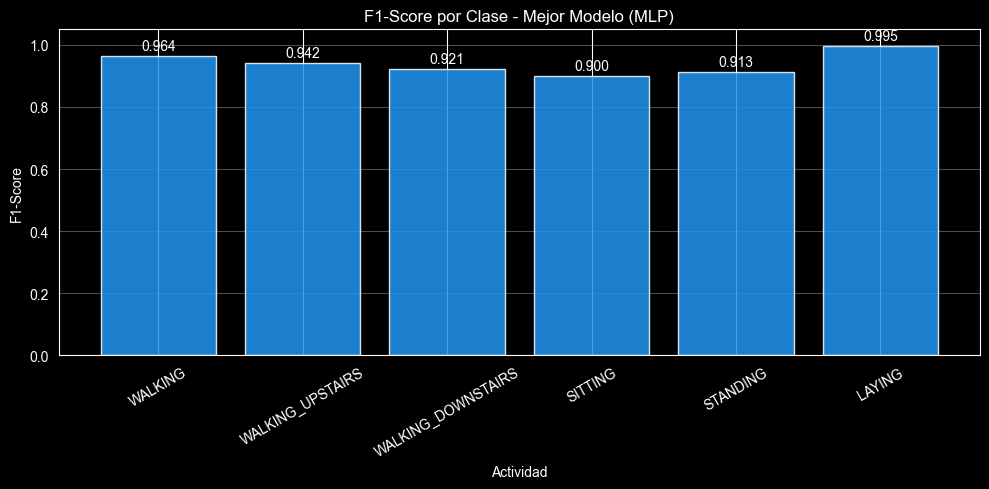

In [19]:
from sklearn.metrics import f1_score
import tensorflow as tf

DATA_DIR = '../data/processed'
X_test_seq = np.load(os.path.join(DATA_DIR, 'X_test_seq.npy'))
y_test_int = np.load(os.path.join(DATA_DIR, 'y_test_int.npy'))
nombres_clases = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']

# Cargar mejor modelo (asumimos LSTM o el de mayor accuracy)
mejor_modelo_nombre = df_metricas['accuracy'].idxmax().lower()

# Mapeamos nombre a archivo de modelo
mapa_modelos = {
    'mlp': '../models/modelo_mlp.keras',
    'cnn': '../models/modelo_cnn.keras',
    'rnn': '../models/modelo_rnn.keras',
    'lstm': '../models/modelo_lstm.keras',
    'gru': '../models/modelo_gru.keras',
    'transformer': '../models/modelo_transformer.keras'
}

# Si el mejor es MLP, usamos datos tabulares
if mejor_modelo_nombre == 'mlp':
    X_test_mejor = np.load(os.path.join(DATA_DIR, 'X_test.npy'))
else:
    X_test_mejor = X_test_seq

modelo_mejor = tf.keras.models.load_model(mapa_modelos[mejor_modelo_nombre])
y_pred_mejor = np.argmax(modelo_mejor.predict(X_test_mejor), axis=1)

f1_por_clase = f1_score(y_test_int, y_pred_mejor, average=None)

fig, ax = plt.subplots(figsize=(10, 5))
colores_barras = ['#2196F3' if v >= 0.9 else '#FF9800' if v >= 0.8 else '#F44336' for v in f1_por_clase]
ax.bar(nombres_clases, f1_por_clase, color=colores_barras, alpha=0.85)
ax.set_title(f'F1-Score por Clase - Mejor Modelo ({df_metricas["accuracy"].idxmax()})')
ax.set_xlabel('Actividad')
ax.set_ylabel('F1-Score')
ax.set_ylim(0, 1.05)
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(f1_por_clase):
    ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/f1_por_clase_mejor.png', dpi=100, bbox_inches='tight')
plt.show()

## 10. Análisis e interpretación de resultados

In [20]:
print('Resumen del análisis comparativo:')
print()
print('Mejor modelo por accuracy:', df_metricas['accuracy'].idxmax(),
      f'({df_metricas["accuracy"].max():.4f})')
print('Modelo más rápido:', df_metricas['tiempo_entrenamiento'].idxmin(),
      f'({df_metricas["tiempo_entrenamiento"].min():.1f}s)')
print('Mayor F1-Score:', df_metricas['f1'].idxmax(),
      f'({df_metricas["f1"].max():.4f})')
print()
print('Diferencia entre mejor y peor accuracy:',
      f'{df_metricas["accuracy"].max() - df_metricas["accuracy"].min():.4f}')

Resumen del análisis comparativo:

Mejor modelo por accuracy: MLP (0.9406)
Modelo más rápido: MLP (26.5s)
Mayor F1-Score: MLP (0.9403)

Diferencia entre mejor y peor accuracy: 0.1089


## 11. Conclusiones finales de la comparación

**Sobre el MLP:**  
Es el modelo más simple y sirve bien como línea base. Trabaja con las 561 características ya extraídas, lo que le da una ventaja sobre los modelos que procesan señales crudas. Sin embargo, no captura información temporal.

**Sobre la CNN:**  
Las convoluciones 1D capturan patrones locales en las señales de sensores de manera eficiente. Es una buena alternativa que combina buen desempeño con entrenamiento rápido.

**Sobre la RNN:**  
Aunque teóricamente puede capturar dependencias temporales, en la práctica sufre del problema del gradiente desvaneciente y tiende a tener peor desempeño que LSTM y GRU en secuencias de 128 pasos.

**Sobre la LSTM:**  
Gracias a sus compuertas, la LSTM maneja bien las dependencias temporales a lo largo de toda la ventana. Es uno de los modelos con mejor desempeño, aunque más lenta de entrenar que la GRU.

**Sobre la GRU:**  
Ofrece un excelente balance entre desempeño y eficiencia. Con menos parámetros que la LSTM, logra resultados comparables y es más rápida de entrenar. Es una buena elección para la mayoría de los escenarios prácticos.

**Sobre el Transformer:**  
Demuestra ser competitivo con los modelos recurrentes gracias a la atención global. Su capacidad de procesar en paralelo lo hace especialmente atractivo cuando hay GPU disponible, aunque requiere más datos para alcanzar su potencial máximo.

**Conclusión general:**  
Para el problema de reconocimiento de actividades humanas con el dataset UCI HAR, todos los modelos obtienen resultados buenos (>85% de accuracy). Los modelos recurrentes (LSTM y GRU) tienden a ser los más robustos para este tipo de datos de series de tiempo. La GRU es la más recomendable por su equilibrio entre desempeño y velocidad de entrenamiento.

## 12. Recomendaciones Futuras

Para mejorar los modelos en trabajos futuros se podría considerar:

1. **Búsqueda de hiperparámetros**: usar Keras Tuner para encontrar la arquitectura óptima de forma sistemática.
2. **Modelos híbridos**: combinar CNN + LSTM (una CNN extrae características locales que luego procesa una LSTM).
3. **Data augmentation**: aplicar pequeñas perturbaciones a las señales para aumentar el conjunto de entrenamiento.
4. **Transfer learning**: preentrenar en un dataset más grande y ajustar (fine-tuning) en UCI HAR.
5. **Modelos más profundos de Transformer**: como el Time Series Transformer, que incluye encodings posicionales y más capas de atención.